<a href="https://colab.research.google.com/github/opaiot/ia-otimizacao-iot-industrias-negocios-public/blob/feature%2Fsync-colab/M1/colab/M1_Aulas_7_9_Aplica%C3%A7%C3%A3o_Pr%C3%A1tica_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

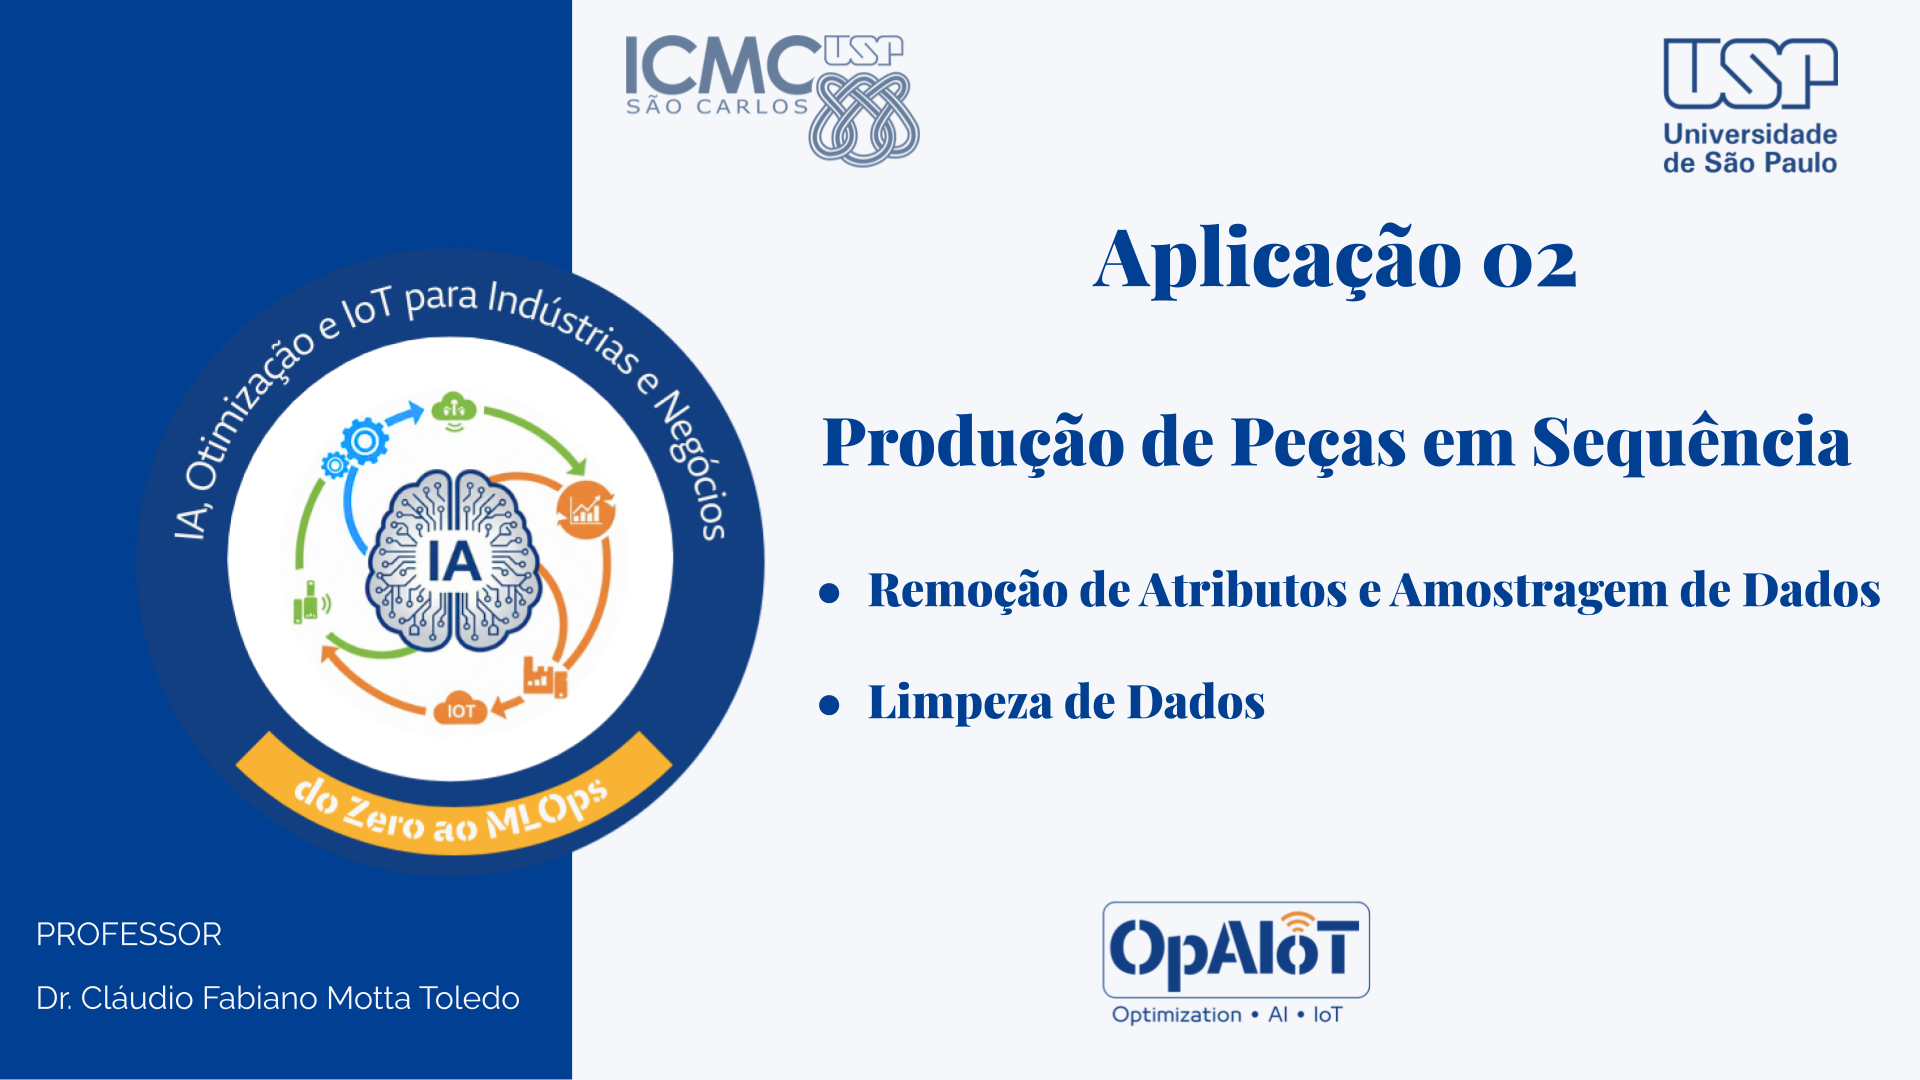

# Aula prática — Tratamento de dados: remoção de atributos, limpeza, imputação e outliers

A proposta é trabalhar com uma base que contém, de forma controlada:

- dados incompletos;
- dados inconsistentes;
- dados redundantes;
- ruídos;
- outliers.

O objetivo é aprender a identificar e tratar esses problemas antes de usar os dados em análises estatísticas ou em modelos de aprendizado de máquina.



## 1. Contexto do problema industrial

Imagine uma linha de produção automatizada que fabrica peças industriais. Sensores registram, a cada hora, informações sobre o processo produtivo.

A equipe de engenharia quer analisar a **taxa de defeitos (%)** e entender se problemas de qualidade estão associados a variáveis como temperatura, pressão, vibração e tempo de ciclo.

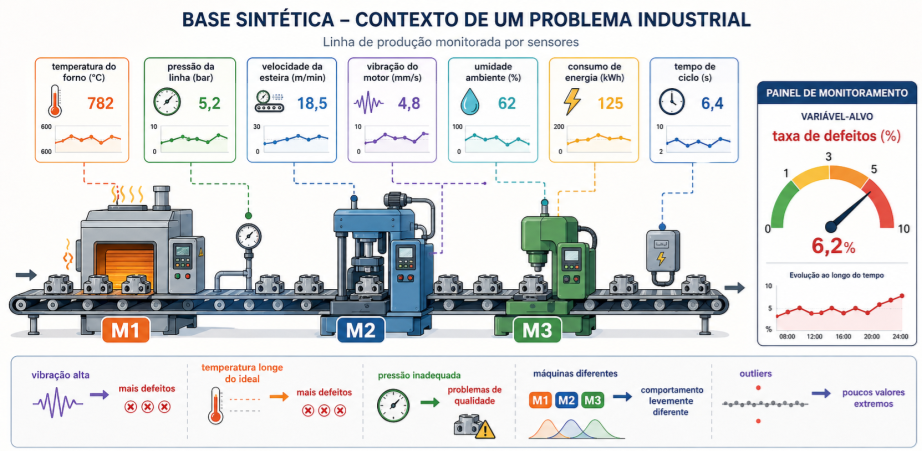


Na prática, porém, dados industriais raramente chegam perfeitos. Eles podem conter:

| Problema | Descrição | Exemplo no contexto industrial |
|---|---|---|
| Dados incompletos | Campos vazios ou nulos | Sensor de vibração não registrou valor em alguns horários |
| Dados inconsistentes | Formatos, unidades ou categorias diferentes | Temperatura em °C e °F na mesma coluna |
| Dados redundantes | Informação repetida ou quase repetida | Duas colunas com a mesma pressão |
| Ruídos | Pequenas variações, erros de digitação ou registros pouco confiáveis | Turno escrito como `Manhã`, `manha`, `MANHA` |
| Outliers | Valores muito distantes do padrão esperado | Vibração extremamente alta em um período |

Neste notebook, vamos criar uma base sintética com esses problemas e depois tratá-la passo a passo.


## 2. Bibliotecas usadas

Nesta célula, importamos as bibliotecas necessárias.

Principais recursos:

- `numpy`: geração de números aleatórios e cálculos numéricos.
- `pandas`: manipulação de tabelas de dados.
- `matplotlib.pyplot`: criação de gráficos.
- `seaborn`: gráficos estatísticos.
- `re`: expressões regulares para extrair números de textos.
- `unicodedata`: remoção de acentos em textos.
- `scipy.stats.zscore`: cálculo do z-score.
- `StandardScaler`: padronização das variáveis para usar no DBSCAN.
- `DBSCAN`: algoritmo usado para identificar pontos anômalos em análise multivariada.

O uso de `DBSCAN` vem do `scikit-learn`. Como a turma ainda tem baixo conhecimento nessa biblioteca, o notebook usa esse recurso de forma bem guiada.


In [ ]:
# ------------------------------------------------------------
# 1) Importação das bibliotecas
# ------------------------------------------------------------

import re
import unicodedata

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from scipy.stats import zscore
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN

pd.set_option("display.max_columns", 40)
pd.set_option("display.precision", 3)

sns.set_theme(style="whitegrid")

print("Bibliotecas importadas com sucesso!")


Bibliotecas importadas com sucesso!


## 3. Geração de uma base sintética com problemas de qualidade

Agora vamos criar uma base de dados propositalmente “suja”. Principais recursos usados:

- `np.random.default_rng(42)`: cria um gerador de números aleatórios reprodutível.
- `rng.normal(...)`: gera valores numéricos com variação em torno de uma média.
- `rng.choice(...)`: sorteia categorias.
- `pd.DataFrame(...)`: cria a tabela.
- `pd.concat(...)`: junta tabelas, usado aqui para adicionar duplicatas.
- `.to_csv(...)`: salva o arquivo em formato CSV.


In [ ]:
# ------------------------------------------------------------
# 2) Geração da base sintética "suja"
# ------------------------------------------------------------

rng = np.random.default_rng(42)
n = 520

# Datas horárias
datas = pd.date_range(start="2026-01-01 00:00:00", periods=n, freq="h")

# Variáveis categóricas inicialmente padronizadas
maquina = rng.choice(["M1", "M2", "M3"], size=n, p=[0.40, 0.35, 0.25])
turno = rng.choice(["Manhã", "Tarde", "Noite"], size=n, p=[0.38, 0.34, 0.28])
produto = rng.choice(["Peça A", "Peça B", "Peça C"], size=n, p=[0.45, 0.35, 0.20])

# Ajustes por máquina
ajuste_temp = np.where(maquina == "M1", -1.0, np.where(maquina == "M2", 0.5, 1.5))
ajuste_vib = np.where(maquina == "M1", -0.2, np.where(maquina == "M2", 0.15, 0.55))

# Sensores em escala realista
temperatura_c = rng.normal(180, 5, n) + ajuste_temp
pressao_bar = rng.normal(6.0, 0.45, n)
velocidade_m_min = rng.normal(32, 3.0, n)
vibracao_mm_s = rng.normal(3.0, 0.65, n) + ajuste_vib
umidade_pct = rng.normal(55, 9, n)
tempo_ciclo_s = rng.normal(42, 4, n)

pressao_bar = np.clip(pressao_bar, 4.5, 7.5)
velocidade_m_min = np.clip(velocidade_m_min, 20, 45)
vibracao_mm_s = np.clip(vibracao_mm_s, 1.0, 7.0)
umidade_pct = np.clip(umidade_pct, 20, 90)
tempo_ciclo_s = np.clip(tempo_ciclo_s, 28, 62)

desvio_temp = np.abs(temperatura_c - 180)

taxa_defeitos_pct = (
    1.8
    + 0.70 * vibracao_mm_s
    + 0.25 * desvio_temp
    + 0.40 * np.maximum(0, 5.8 - pressao_bar)
    + 0.025 * umidade_pct
    + rng.normal(0, 1.0, n)
)

taxa_defeitos_pct = np.clip(taxa_defeitos_pct, 0.1, 18)

consumo_energia_kwh = (
    60
    + 0.20 * (temperatura_c - 180)
    + 0.50 * velocidade_m_min
    + 0.30 * tempo_ciclo_s
    + rng.normal(0, 3.0, n)
)

# Criação da base inicialmente limpa
df = pd.DataFrame({
    "id_registro": np.arange(1, n + 1),
    "data_coleta": datas,
    "maquina": maquina,
    "turno": turno,
    "produto": produto,
    "temperatura_forno": temperatura_c,
    "pressao_linha": pressao_bar,
    "velocidade_esteira_m_min": velocidade_m_min,
    "vibracao_motor_mm_s": vibracao_mm_s,
    "umidade_ambiente_pct": umidade_pct,
    "consumo_energia_kwh": consumo_energia_kwh,
    "consumo_energia_kwh_estimado": consumo_energia_kwh + rng.normal(0, 0.2, n),  # quase redundante
    "tempo_ciclo_s": tempo_ciclo_s,
    "taxa_defeitos_pct": taxa_defeitos_pct,
})

# ------------------------------------------------------------
# Introdução proposital de inconsistências
# ------------------------------------------------------------

# 1) Datas em formatos diferentes
data_texto = []
for i, data in enumerate(df["data_coleta"]):
    if i % 4 == 0:
        data_texto.append(data.strftime("%d/%m/%Y %H:%M"))
    elif i % 4 == 1:
        data_texto.append(data.strftime("%Y-%m-%d %H:%M:%S"))
    elif i % 4 == 2:
        data_texto.append(data.strftime("%d-%m-%Y %H:%M"))
    else:
        data_texto.append(data.strftime("%Y/%m/%d %H:%M"))

df["data_coleta"] = data_texto

# 2) Temperatura em C e F na mesma coluna
temperatura_texto = []
for valor in df["temperatura_forno"]:
    if rng.random() < 0.18:
        valor_f = valor * 9/5 + 32
        temperatura_texto.append(f"{valor_f:.1f} F")
    else:
        temperatura_texto.append(f"{valor:.1f} C")

df["temperatura_forno"] = temperatura_texto

# 3) Pressão em bar e psi na mesma coluna
pressao_texto = []
for valor in df["pressao_linha"]:
    if rng.random() < 0.20:
        valor_psi = valor * 14.5038
        pressao_texto.append(f"{valor_psi:.1f} psi")
    else:
        # Alguns valores com vírgula decimal, comuns em planilhas brasileiras
        if rng.random() < 0.25:
            pressao_texto.append(f"{valor:.2f}".replace(".", ",") + " bar")
        else:
            pressao_texto.append(f"{valor:.2f} bar")

df["pressao_linha"] = pressao_texto

# 4) Categorias com variações de escrita
variantes_maquina = {
    "M1": ["M1", "m1", "M-1", "Maquina 1", "Máquina 1", "M 1"],
    "M2": ["M2", "m2", "M-2", "Maquina 2", "Máquina 2", "M 2"],
    "M3": ["M3", "m3", "M-3", "Maquina 3", "Máquina 3", "M 3"],
}

variantes_turno = {
    "Manhã": ["Manhã", "manha", "MANHA", "Manha ", " manhã"],
    "Tarde": ["Tarde", "tarde", "TARDE", "Tarde "],
    "Noite": ["Noite", "noite", "NOITE", " Noite"],
}

variantes_produto = {
    "Peça A": ["Peça A", "Peca A", "peça a", "A"],
    "Peça B": ["Peça B", "Peca B", "peça b", "B"],
    "Peça C": ["Peça C", "Peca C", "peça c", "C"],
}

df["maquina"] = [rng.choice(variantes_maquina[x]) for x in df["maquina"]]
df["turno"] = [rng.choice(variantes_turno[x]) for x in df["turno"]]
df["produto"] = [rng.choice(variantes_produto[x]) for x in df["produto"]]

# 5) Colunas redundantes
df["pressao_linha_backup"] = df["pressao_linha"]       # duplicata exata
df["planta"] = "Unidade_A"                            # coluna constante
df["observacao_operador"] = pd.Series([np.nan] * n, dtype="object")  # quase totalmente ausente

# Algumas observações pontuais
idx_obs = rng.choice(df.index, size=18, replace=False)
df.loc[idx_obs, "observacao_operador"] = rng.choice(
    ["ruido no sensor", "parada curta", "ajuste manual"], size=18
)

# 6) Valores ausentes
colunas_com_missing = [
    "data_coleta",
    "maquina",
    "turno",
    "produto",
    "temperatura_forno",
    "pressao_linha",
    "vibracao_motor_mm_s",
    "umidade_ambiente_pct",
    "tempo_ciclo_s",
    "taxa_defeitos_pct"
]

for coluna in colunas_com_missing:
    idx_missing = rng.choice(df.index, size=int(0.05 * n), replace=False)
    df.loc[idx_missing, coluna] = np.nan

# 7) Inconsistências explícitas
idx_data_ruim = rng.choice(df.index, size=8, replace=False)
df.loc[idx_data_ruim, "data_coleta"] = "sem data"

idx_temp_ruim = rng.choice(df.index, size=8, replace=False)
df.loc[idx_temp_ruim, "temperatura_forno"] = "erro"

idx_pressao_ruim = rng.choice(df.index, size=8, replace=False)
df.loc[idx_pressao_ruim, "pressao_linha"] = "??"

idx_umidade_ruim = rng.choice(df.index, size=7, replace=False)
df.loc[idx_umidade_ruim, "umidade_ambiente_pct"] = rng.choice([-10, 130, 150], size=7)

idx_tempo_ruim = rng.choice(df.index, size=7, replace=False)
df.loc[idx_tempo_ruim, "tempo_ciclo_s"] = rng.choice([-5, 0, 200], size=7)

# 8) Outliers numéricos
idx_outliers = rng.choice(df.index, size=10, replace=False)
df.loc[idx_outliers, "vibracao_motor_mm_s"] = rng.normal(9.0, 0.4, size=10)
df.loc[idx_outliers, "taxa_defeitos_pct"] = rng.normal(22, 2.0, size=10)

# Garantimos que o backup seja uma duplicata exata da coluna de pressão após todas as alterações
df["pressao_linha_backup"] = df["pressao_linha"]

# 9) Duplicação de linhas
duplicatas = df.sample(25, random_state=42)
df_sujo = pd.concat([df, duplicatas], ignore_index=True)

# Arredonda valores numéricos para simular sensores
for coluna in df_sujo.select_dtypes(include="number").columns:
    df_sujo[coluna] = df_sujo[coluna].round(2)

# Salva CSV sujo
arquivo_sujo = "dados_linha_producao_sujos.csv"
df_sujo.to_csv(arquivo_sujo, index=False)

print(f"Arquivo salvo: {arquivo_sujo}")
print("Dimensões da base suja:", df_sujo.shape)

display(df_sujo.head(10))


Arquivo salvo: dados_linha_producao_sujos.csv
Dimensões da base suja: (545, 17)


,id_registro,data_coleta,maquina,turno,produto,temperatura_forno,pressao_linha,velocidade_esteira_m_min,vibracao_motor_mm_s,umidade_ambiente_pct,consumo_energia_kwh,consumo_energia_kwh_estimado,tempo_ciclo_s,taxa_defeitos_pct,pressao_linha_backup,planta,observacao_operador
0,1,01/01/2026 00:00,M-3,Noite,Peca A,175.2 C,93.0 psi,33.08,3.25,63.71,87.24,87.13,39.42,8.40,93.0 psi,Unidade_A,NaN
1,2,2026-01-01 01:00:00,Maquina 2,manha,Peça B,166.8 C,91.3 psi,32.14,2.43,76.76,82.46,82.84,44.93,8.12,91.3 psi,Unidade_A,NaN
2,3,NaN,M-3,MANHA,Peça B,180.3 C,6.86 bar,35.98,3.70,NaN,94.31,94.23,38.00,6.42,6.86 bar,Unidade_A,NaN
3,4,2026/01/01 03:00,M 2,Tarde,Peca B,179.6 C,5.66 bar,37.05,8.87,68.12,91.99,91.82,43.43,21.71,5.66 bar,Unidade_A,NaN
4,5,01/01/2026 04:00,Máquina 1,Manha,Peca A,350.4 F,5.38 bar,35.40,2.49,55.63,87.86,87.66,44.99,5.84,5.38 bar,Unidade_A,NaN
5,6,2026-01-01 05:00:00,M-3,manhã,peça a,186.9 C,5.55 bar,29.18,4.03,62.25,86.36,86.02,41.65,7.16,5.55 bar,Unidade_A,NaN
6,7,01-01-2026 06:00,NaN,NOITE,Peca A,187.5 C,6.30 bar,32.60,2.79,40.17,85.94,86.25,46.04,NaN,6.30 bar,Unidade_A,NaN
7,8,2026/01/01 07:00,Maquina 3,Noite,Peça B,180.6 C,NaN,33.32,NaN,68.21,85.73,86.00,40.78,4.98,NaN,Unidade_A,NaN
8,9,01/01/2026 08:00,Maquina 1,NOITE,Peça C,168.3 C,"6,05 bar",26.57,2.90,62.08,86.34,86.46,NaN,8.47,"6,05 bar",Unidade_A,NaN
9,10,2026-01-01 09:00:00,Maquina 2,Manha,peça a,183.6 C,79.7 psi,33.41,3.78,54.65,95.54,95.36,NaN,6.59,79.7 psi,Unidade_A,NaN


## 4. Leitura do arquivo CSV com `pd.read_csv()`

Agora vamos simular o fluxo comum de trabalho: o arquivo foi gerado e salvo, então vamos lê-lo novamente com `pd.read_csv()`.

Principais recursos:

- `pd.read_csv("arquivo.csv")`: lê um arquivo CSV.
- `.head()`: mostra as primeiras linhas.
- `.shape`: mostra quantidade de linhas e colunas.
- `.info()`: mostra tipos das colunas e presença de valores nulos.

Este passo é importante porque muitos problemas aparecem já na leitura dos dados.


In [ ]:
# ------------------------------------------------------------
# 3) Leitura da base suja
# ------------------------------------------------------------

dados_sujos = pd.read_csv("dados_linha_producao_sujos.csv")

print("Dimensões:", dados_sujos.shape)

print("\nPrimeiras linhas:")
display(dados_sujos.head())

print("\nInformações da base:")
dados_sujos.info()


Dimensões: (545, 17)

Primeiras linhas:


,id_registro,data_coleta,maquina,turno,produto,temperatura_forno,pressao_linha,velocidade_esteira_m_min,vibracao_motor_mm_s,umidade_ambiente_pct,consumo_energia_kwh,consumo_energia_kwh_estimado,tempo_ciclo_s,taxa_defeitos_pct,pressao_linha_backup,planta,observacao_operador
0,1,01/01/2026 00:00,M-3,Noite,Peca A,175.2 C,93.0 psi,33.08,3.25,63.71,87.24,87.13,39.42,8.40,93.0 psi,Unidade_A,NaN
1,2,2026-01-01 01:00:00,Maquina 2,manha,Peça B,166.8 C,91.3 psi,32.14,2.43,76.76,82.46,82.84,44.93,8.12,91.3 psi,Unidade_A,NaN
2,3,NaN,M-3,MANHA,Peça B,180.3 C,6.86 bar,35.98,3.70,NaN,94.31,94.23,38.00,6.42,6.86 bar,Unidade_A,NaN
3,4,2026/01/01 03:00,M 2,Tarde,Peca B,179.6 C,5.66 bar,37.05,8.87,68.12,91.99,91.82,43.43,21.71,5.66 bar,Unidade_A,NaN
4,5,01/01/2026 04:00,Máquina 1,Manha,Peca A,350.4 F,5.38 bar,35.40,2.49,55.63,87.86,87.66,44.99,5.84,5.38 bar,Unidade_A,NaN



Informações da base:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   id_registro                   545 non-null    int64  
 1   data_coleta                   519 non-null    object 
 2   maquina                       518 non-null    object 
 3   turno                         518 non-null    object 
 4   produto                       517 non-null    object 
 5   temperatura_forno             517 non-null    object 
 6   pressao_linha                 519 non-null    object 
 7   velocidade_esteira_m_min      545 non-null    float64
 8   vibracao_motor_mm_s           520 non-null    float64
 9   umidade_ambiente_pct          518 non-null    float64
 10  consumo_energia_kwh           545 non-null    float64
 11  consumo_energia_kwh_estimado  545 non-null    float64
 12  tempo_ciclo_s                 518 non-null

### Interpretação da leitura

Observe que colunas como `temperatura_forno` e `pressao_linha` aparecem como `object`, ou seja, texto.

Isso acontece porque essas colunas misturam números com unidades, como `180.5 C`, `354.2 F`, `6,10 bar`, `88.5 psi`, além de valores inválidos.

Essa é uma situação comum em bases reais: antes de analisar, precisamos converter e limpar.


## 5. Diagnóstico inicial de valores ausentes

Valores ausentes podem aparecer como `NaN`, `None`, células vazias ou valores que precisam ser convertidos para nulo.

Principais recursos:

- `.isna()`: retorna `True` quando o valor está ausente.
- `.sum()`: soma os valores `True`, contando os ausentes por coluna.
- `len(dados)`: retorna a quantidade de linhas.
- `pd.DataFrame(...)`: organiza o diagnóstico em tabela.
- `.sort_values(...)`: ordena a tabela.


In [ ]:
# ------------------------------------------------------------
# 4) Diagnóstico de valores ausentes
# ------------------------------------------------------------

ausentes = dados_sujos.isna().sum()
percentual_ausente = 100 * ausentes / len(dados_sujos)

diagnostico_ausentes = pd.DataFrame({
    "valores_ausentes": ausentes,
    "percentual_ausente": percentual_ausente
}).sort_values("percentual_ausente", ascending=False)

display(diagnostico_ausentes)


,valores_ausentes,percentual_ausente
observacao_operador,527,96.697
taxa_defeitos_pct,30,5.505
produto,28,5.138
temperatura_forno,28,5.138
tempo_ciclo_s,27,4.954
turno,27,4.954
umidade_ambiente_pct,27,4.954
maquina,27,4.954
pressao_linha_backup,26,4.771
pressao_linha,26,4.771


### Interpretação dos valores ausentes

A coluna `observacao_operador` deve ter muitos valores ausentes. Isso não é necessariamente um problema se a coluna for apenas uma observação opcional.

Por outro lado, ausência em sensores importantes, como vibração, pressão, temperatura ou taxa de defeitos, precisa ser tratada com mais cuidado.

Em uma análise real, a decisão depende do contexto:

- se faltam poucos valores, podemos imputar;
- se faltam muitos valores em uma coluna pouco útil, podemos removê-la;
- se a ausência tem significado operacional, ela pode virar uma nova variável indicadora.


## 6. Remoção de linhas duplicadas e atributos redundantes

Dados redundantes podem aparecer em duas formas:

1. **Linhas duplicadas**: o mesmo registro aparece mais de uma vez.
2. **Colunas redundantes**: uma coluna repete a informação de outra ou não acrescenta informação útil.

Nesta célula, vamos tratar:

- linhas duplicadas, usando `.duplicated()` e `.drop_duplicates()`;
- colunas constantes, usando `.nunique()`;
- colunas com muitos valores ausentes;
- colunas duplicadas exatamente, usando `.T.duplicated()`.

Principais recursos:

- `.duplicated()`: identifica linhas repetidas.
- `.drop_duplicates()`: remove linhas repetidas.
- `.nunique(dropna=False)`: conta quantos valores distintos existem em cada coluna, sem ignorar valores ausentes.
- `.drop(columns=...)`: remove colunas.


In [ ]:
# ------------------------------------------------------------
# 5) Remoção de duplicatas e colunas redundantes
# ------------------------------------------------------------

dados = dados_sujos.copy()

# 1) Linhas duplicadas
qtd_duplicadas = dados.duplicated().sum()
print(f"Quantidade de linhas duplicadas: {qtd_duplicadas}")

dados = dados.drop_duplicates()
print("Dimensões após remover duplicatas:", dados.shape)

# 2) Colunas constantes
'''A ideia é encontrar colunas que têm no máximo um valor distinto.
Essas colunas geralmente não ajudam em análise ou modelagem,
porque não trazem variação/informação.'''

n_unicos = dados.nunique(dropna=False)
colunas_constantes = list(n_unicos[n_unicos <= 1].index)

print("\nColunas constantes:")
print(colunas_constantes)

# 3) Colunas com muitos valores ausentes
limite_ausencia = 0.80
percentual_ausente = dados.isna().mean()
colunas_muito_ausentes = list(percentual_ausente[percentual_ausente > limite_ausencia].index)

print("\nColunas com mais de 80% de valores ausentes:")
print(colunas_muito_ausentes)

# 4) Colunas duplicadas exatamente
colunas_duplicadas_exatas = list(dados.columns[dados.T.duplicated()])
print("\nColunas duplicadas exatamente:")
print(colunas_duplicadas_exatas)

# União das colunas a remover
#set transforma a lista em um conjunto, removendo elementos repetidos.
#sorted organiza os nomes em ordem alfabética e devolve uma lista.
colunas_remover = sorted(set(colunas_constantes + colunas_muito_ausentes + colunas_duplicadas_exatas))
dados_sem_redundancia = dados.drop(columns=colunas_remover)

print("\nColunas removidas:")
print(colunas_remover)

print("\nDimensões após remover redundâncias:")
print(dados_sem_redundancia.shape)

display(dados_sem_redundancia.head())


Quantidade de linhas duplicadas: 25
Dimensões após remover duplicatas: (520, 17)

Colunas constantes:
['planta']

Colunas com mais de 80% de valores ausentes:
['observacao_operador']

Colunas duplicadas exatamente:
['pressao_linha_backup']

Colunas removidas:
['observacao_operador', 'planta', 'pressao_linha_backup']

Dimensões após remover redundâncias:
(520, 14)


,id_registro,data_coleta,maquina,turno,produto,temperatura_forno,pressao_linha,velocidade_esteira_m_min,vibracao_motor_mm_s,umidade_ambiente_pct,consumo_energia_kwh,consumo_energia_kwh_estimado,tempo_ciclo_s,taxa_defeitos_pct
0,1,01/01/2026 00:00,M-3,Noite,Peca A,175.2 C,93.0 psi,33.08,3.25,63.71,87.24,87.13,39.42,8.40
1,2,2026-01-01 01:00:00,Maquina 2,manha,Peça B,166.8 C,91.3 psi,32.14,2.43,76.76,82.46,82.84,44.93,8.12
2,3,NaN,M-3,MANHA,Peça B,180.3 C,6.86 bar,35.98,3.70,NaN,94.31,94.23,38.00,6.42
3,4,2026/01/01 03:00,M 2,Tarde,Peca B,179.6 C,5.66 bar,37.05,8.87,68.12,91.99,91.82,43.43,21.71
4,5,01/01/2026 04:00,Máquina 1,Manha,Peca A,350.4 F,5.38 bar,35.40,2.49,55.63,87.86,87.66,44.99,5.84


### Interpretação da remoção de redundâncias

A remoção de duplicatas evita que o mesmo registro tenha peso duplicado nas análises.

A remoção de colunas constantes também é importante: se uma coluna tem o mesmo valor em todas as linhas, ela não ajuda a explicar variações no processo.

Colunas com ausência muito alta podem ser removidas quando não são essenciais. Neste exemplo, `observacao_operador` é quase toda ausente e não será usada nas análises numéricas.

Colunas duplicadas exatamente, como um backup repetindo outra coluna, também devem ser removidas para reduzir confusão e evitar análises redundantes.

####Papel do duplicated()

Esse trecho identifica **colunas duplicadas exatamente iguais** dentro do DataFrame `dados`.

```python
colunas_duplicadas_exatas = list(dados.columns[dados.T.duplicated()])
```

A ideia é verificar se existem colunas diferentes com **os mesmos valores em todas as linhas**.

---

Considere este exemplo:

```python
import pandas as pd

dados = pd.DataFrame({
    "temperatura": [100, 105, 110, 108],
    "temp_copia": [100, 105, 110, 108],
    "pressao": [2.1, 2.3, 2.2, 2.4],
    "pressao_backup": [2.1, 2.3, 2.2, 2.4],
    "turno": ["manhã", "tarde", "noite", "manhã"]
})
```

Nesse caso:

```text
temperatura      = [100, 105, 110, 108]
temp_copia       = [100, 105, 110, 108]

pressao          = [2.1, 2.3, 2.2, 2.4]
pressao_backup   = [2.1, 2.3, 2.2, 2.4]
```

Logo, `temp_copia` é duplicada exata de `temperatura`, e `pressao_backup` é duplicada exata de `pressao`.

---

### 1. Uso de `dados.T`

```python
dados.T
```

O `.T` faz a **transposição** do DataFrame, ou seja, transforma colunas em linhas e linhas em colunas.

Originalmente:

```text
   temperatura  temp_copia  pressao  pressao_backup  turno
0          100         100      2.1             2.1  manhã
1          105         105      2.3             2.3  tarde
2          110         110      2.2             2.2  noite
3          108         108      2.4             2.4  manhã
```

Após `dados.T`, as colunas viram linhas:

```text
                   0      1      2      3
temperatura      100    105    110    108
temp_copia       100    105    110    108
pressao          2.1    2.3    2.2    2.4
pressao_backup   2.1    2.3    2.2    2.4
turno          manhã  tarde  noite  manhã
```

Isso é importante porque o método `duplicated()` normalmente verifica **linhas duplicadas**. Como queremos verificar **colunas duplicadas**, primeiro transformamos as colunas em linhas.

---

### 2. Uso do `.duplicated()`

```python
dados.T.duplicated()
```

Agora o pandas verifica quais **linhas transpostas** são duplicadas.

Resultado aproximado:

```text
temperatura       False
temp_copia         True
pressao           False
pressao_backup     True
turno             False
dtype: bool
```

Interpretação:

| coluna original  | resultado | significado                                   |
| ---------------- | --------: | --------------------------------------------- |
| `temperatura`    |   `False` | primeira ocorrência desse conjunto de valores |
| `temp_copia`     |    `True` | duplicada de `temperatura`                    |
| `pressao`        |   `False` | primeira ocorrência desse conjunto de valores |
| `pressao_backup` |    `True` | duplicada de `pressao`                        |
| `turno`          |   `False` | não é duplicada                               |

Por padrão, `duplicated()` marca como `False` a primeira ocorrência e como `True` as repetições seguintes.

---

### 3. Uso de `dados.columns[...]`

```python
dados.columns[dados.T.duplicated()]
```

Essa parte usa a sequência de `True` e `False` para selecionar os nomes das colunas duplicadas.

No exemplo, selecionaria:

```python
Index(["temp_copia", "pressao_backup"], dtype="object")
```

---

### 4. Uso de `list(...)`

```python
list(dados.columns[dados.T.duplicated()])
```

Transforma o resultado em uma lista comum do Python:

```python
["temp_copia", "pressao_backup"]
```

---

### Resultado final

```python
colunas_duplicadas_exatas = ["temp_copia", "pressao_backup"]
```

Essas são as colunas que podem ser candidatas à remoção, porque repetem exatamente a informação de outras colunas.

Você poderia removê-las assim:

```python
dados = dados.drop(columns=colunas_duplicadas_exatas)
```

Em resumo, esse código encontra colunas redundantes que possuem exatamente os mesmos valores de outras colunas do DataFrame.


## 7. Identificação de inconsistências em categorias

Agora vamos observar como as categorias aparecem na base.

Problemas comuns:

- espaços extras;
- letras maiúsculas e minúsculas misturadas;
- acentos;
- abreviações diferentes;
- nomes diferentes para a mesma entidade.

Principais recursos:

- `.value_counts(dropna=False)`: conta as ocorrências de cada valor, incluindo ausentes.
- `for`: repete o diagnóstico para várias colunas.


In [ ]:
# ------------------------------------------------------------
# 6) Diagnóstico de categorias inconsistentes
# ------------------------------------------------------------

dados_cat = dados_sem_redundancia.copy()

for coluna in ["maquina", "turno", "produto"]:
    print(f"\nValores encontrados na coluna: {coluna}")
    display(dados_cat[coluna].value_counts(dropna=False).to_frame("contagem"))



Valores encontrados na coluna: maquina


,contagem
maquina,
Máquina 1,43
M2,36
M 1,35
M1,34
M-2,32
M 2,32
m1,32
m2,29
M-3,29



Valores encontrados na coluna: turno


,contagem
turno,
Tarde,53
manha,47
TARDE,44
Manhã,41
NOITE,39
Noite,38
manhã,36
Tarde,36
noite,35



Valores encontrados na coluna: produto


,contagem
produto,
peça a,69
Peça A,56
A,55
Peca A,46
Peca B,43
peça b,41
B,40
Peça B,38
Peca C,35


## 8. Padronização de categorias textuais

Nesta etapa, vamos limpar textos.

Principais recursos:

- `.astype("string")`: trata a coluna como texto.
- `.str.strip()`: remove espaços antes e depois do texto.
- `.str.lower()`: transforma letras em minúsculas.
- `unicodedata.normalize(...)`: ajuda a remover acentos.
- dicionários Python: usados para mapear variações para um padrão.

A função `normalizar_texto` será usada para transformar textos como `Máquina 1`, `maquina 1`, `M-1` e `M 1` em formas mais fáceis de mapear.


In [ ]:
# ------------------------------------------------------------
# 7) Padronização de categorias
# ------------------------------------------------------------

def normalizar_texto(valor):
    """
    Padroniza textos para facilitar comparação:
    - converte para string;
    - remove espaços extras;
    - coloca em minúsculas;
    - remove acentos.
    """
    if pd.isna(valor): #np.nan, np.NA, None
        return np.nan

    texto = str(valor).strip().lower() # " Manhã  " => "manhã"
    texto = unicodedata.normalize("NFKD", texto) # "manhã"=> "manha~"
    texto = "".join([c for c in texto if not unicodedata.combining(c)])
    # "manha~" => "manha"

    texto = re.sub(r"\s+", " ", texto)
    '''Essa linha substitui sequências de espaços, quebra de linha
    e tabulações por um único espaço
             "turno    da    noite" =: "turno da noite"'''

    return texto


dados_padronizados = dados_sem_redundancia.copy()

# Criação de versões normalizadas temporárias
dados_padronizados["maquina_norm"] = dados_padronizados["maquina"].apply(normalizar_texto)
dados_padronizados["turno_norm"] = dados_padronizados["turno"].apply(normalizar_texto)
dados_padronizados["produto_norm"] = dados_padronizados["produto"].apply(normalizar_texto)

mapa_maquina = {
    "m1": "M1", "m-1": "M1", "m 1": "M1", "maquina 1": "M1",
    "m2": "M2", "m-2": "M2", "m 2": "M2", "maquina 2": "M2",
    "m3": "M3", "m-3": "M3", "m 3": "M3", "maquina 3": "M3",
}

mapa_turno = {
    "manha": "Manhã",
    "tarde": "Tarde",
    "noite": "Noite",
}

mapa_produto = {
    "peca a": "Peça A", "a": "Peça A",
    "peca b": "Peça B", "b": "Peça B",
    "peca c": "Peça C", "c": "Peça C",
}

dados_padronizados["maquina"] = dados_padronizados["maquina_norm"].map(mapa_maquina)
dados_padronizados["turno"] = dados_padronizados["turno_norm"].map(mapa_turno)
dados_padronizados["produto"] = dados_padronizados["produto_norm"].map(mapa_produto)

# Removemos as colunas temporárias
dados_padronizados = dados_padronizados.drop(columns=["maquina_norm", "turno_norm", "produto_norm"])

for coluna in ["maquina", "turno", "produto"]:
    print(f"\nValores padronizados na coluna: {coluna}")
    display(dados_padronizados[coluna].value_counts(dropna=False).to_frame("contagem"))



Valores padronizados na coluna: maquina


,contagem
maquina,
M1,196
M2,175
M3,123
NaN,26



Valores padronizados na coluna: turno


,contagem
turno,
Manhã,186
Tarde,164
Noite,144
NaN,26



Valores padronizados na coluna: produto


,contagem
produto,
Peça A,226
Peça B,162
Peça C,106
NaN,26


### Interpretação da padronização

Depois da padronização, categorias equivalentes passam a ter o mesmo nome.

Isso evita erros como tratar `M1`, `m1`, `M-1` e `Máquina 1` como máquinas diferentes.

Essa etapa é muito importante antes de calcular médias por máquina, fazer gráficos por turno ou usar categorias em modelos de aprendizado de máquina.


## 9. Tratamento de datas, unidades e valores fisicamente inconsistentes

Agora vamos tratar inconsistências mais complexas:

- datas em múltiplos formatos;
- temperatura misturada em °C e °F;
- pressão misturada em `bar` e `psi`;
- umidade fora do intervalo possível;
- tempo de ciclo negativo ou extremamente alto.

Principais recursos:

- `pd.to_datetime(..., errors="coerce")`: tenta converter texto em data. Valores inválidos viram `NaT`.
- expressões regulares com `re.search(...)`: extraem números de textos.
- `np.nan`: representa valor ausente após identificarmos uma inconsistência.
- `.loc[condição, coluna]`: altera valores que satisfazem uma condição.

Em limpeza de dados, é comum transformar inconsistências em valores ausentes para depois imputá-los ou removê-los.


## Procurar número com expressão regular com re.search()

```python
encontrado = re.search(r"[-+]?\d*\.?\d+", texto)
```

Ela usa `re.search()`, da biblioteca `re`, para procurar um padrão dentro do texto. A biblioteca `re` é a biblioteca padrão do Python para trabalhar com expressões regulares, também chamadas de `regex`. Expressões regulares são padrões usados para procurar, validar, extrair ou substituir partes de textos.
O padrão aqui será:

```python
r"[-+]?\d*\.?\d+"
```

Esse padrão procura números como:

```python
180
180.5
-10
+25
0.75
.75
```

### Componentes do padrão

| trecho  | significado                         |
| ------- | ----------------------------------- |
| `[-+]?` | sinal positivo ou negativo opcional |
| `\d*`   | zero ou mais dígitos antes do ponto |
| `\.?`   | ponto decimal opcional              |
| `\d+`   | um ou mais dígitos obrigatórios     |

Então, em:

```python
"temperatura = 180.5 C"
```

a função encontra:

```python
"180.5"
```

Em:

```python
"pressao: 6.10 bar"
```

a função encontra:

```python
"6.10"
```

---

## Se encontrou número, converte para `float`

```python
if encontrado:
    return float(encontrado.group())
```

Se `re.search()` encontrou um número, ele retorna um objeto de correspondência.
O objeto encontrado não é diretamente o texto "180.5". Ele é um objeto de correspondência do Python, chamado Match. A chamada:

```python
encontrado.group()
```

pega o texto encontrado. Exemplo:

```python
"180.5"
```

Depois:

```python
float(...)
```
converte esse texto para número decimal.Resultado:

```python
180.5
```

---


In [ ]:
# ------------------------------------------------------------
# 8) Tratamento de datas, unidades e inconsistências físicas
# ------------------------------------------------------------

dados_tratados = dados_padronizados.copy()

def converter_data_mista(valor):
    """
    Converte datas em diferentes formatos para datetime.
    Se não conseguir converter, retorna NaT.
    """
    if pd.isna(valor):
        return pd.NaT

    formatos = [
        "%d/%m/%Y %H:%M",
        "%Y-%m-%d %H:%M:%S",
        "%d-%m-%Y %H:%M",
        "%Y/%m/%d %H:%M",
    ]

    for formato in formatos:
        data = pd.to_datetime(valor, format=formato, errors="coerce")
        ''' errors="coerce": Se não conseguir converter, não gere erro;
        transforme o resultado em NaT'''
        if not pd.isna(data):
            return data

    return pd.NaT


def extrair_numero(texto):
    """
    Extrai o primeiro número encontrado em um texto.
    Aceita vírgula ou ponto decimal.
    """
    if pd.isna(texto):
        return np.nan

    texto = str(texto).replace(",", ".")
    encontrado = re.search(r"[-+]?\d*\.?\d+", texto)

    if encontrado:
        return float(encontrado.group())

    return np.nan


def converter_temperatura_para_celsius(valor):
    """
    Converte temperatura para Celsius.
    Exemplos:
    - '180.2 C' continua 180.2
    - '356.0 F' vira aproximadamente 180.0
    - 'erro' vira NaN
    """
    if pd.isna(valor):
        return np.nan

    texto = str(valor).strip().lower()
    numero = extrair_numero(texto)

    if pd.isna(numero):
        return np.nan

    if "f" in texto:
        return (numero - 32) * 5/9

    return numero


def converter_pressao_para_bar(valor):
    """
    Converte pressão para bar.
    Exemplos:
    - '6.10 bar' continua 6.10
    - '88.5 psi' vira aproximadamente 6.10 bar
    - '??' vira NaN
    """
    if pd.isna(valor):
        return np.nan

    texto = str(valor).strip().lower()
    numero = extrair_numero(texto)

    if pd.isna(numero):
        return np.nan

    if "psi" in texto:
        return numero / 14.5038

    return numero

#Criando colunas ajustadas
dados_tratados["data_coleta"] = dados_tratados["data_coleta"].apply(converter_data_mista)
dados_tratados["temperatura_forno_c"] = dados_tratados["temperatura_forno"].apply(converter_temperatura_para_celsius)
dados_tratados["pressao_linha_bar"] = dados_tratados["pressao_linha"].apply(converter_pressao_para_bar)

# Removemos as colunas originais textuais, pois agora temos versões padronizadas numéricas
dados_tratados = dados_tratados.drop(columns=["temperatura_forno", "pressao_linha"])

# Tratamento de valores fisicamente inconsistentes
dados_tratados.loc[
    (dados_tratados["umidade_ambiente_pct"] < 0) | (dados_tratados["umidade_ambiente_pct"] > 100),
    "umidade_ambiente_pct"
] = np.nan

dados_tratados.loc[
    (dados_tratados["tempo_ciclo_s"] <= 0) | (dados_tratados["tempo_ciclo_s"] > 120),
    "tempo_ciclo_s"
] = np.nan

# Também podemos marcar como ausentes pressões e temperaturas fora de uma faixa muito plausível
dados_tratados.loc[
    (dados_tratados["pressao_linha_bar"] < 3) | (dados_tratados["pressao_linha_bar"] > 10),
    "pressao_linha_bar"
] = np.nan

dados_tratados.loc[
    (dados_tratados["temperatura_forno_c"] < 140) | (dados_tratados["temperatura_forno_c"] > 220),
    "temperatura_forno_c"
] = np.nan

print("Tipos após conversões:")
display(dados_tratados.dtypes.to_frame("tipo"))

print("\nValores ausentes após tratar inconsistências:")
display(dados_tratados.isna().sum().to_frame("ausentes"))

display(dados_tratados.head())


Tipos após conversões:


,tipo
id_registro,int64
data_coleta,datetime64[ns]
maquina,object
turno,object
produto,object
velocidade_esteira_m_min,float64
vibracao_motor_mm_s,float64
umidade_ambiente_pct,float64
consumo_energia_kwh,float64
consumo_energia_kwh_estimado,float64



Valores ausentes após tratar inconsistências:


,ausentes
id_registro,0
data_coleta,34
maquina,26
turno,26
produto,26
velocidade_esteira_m_min,0
vibracao_motor_mm_s,24
umidade_ambiente_pct,32
consumo_energia_kwh,0
consumo_energia_kwh_estimado,0


,id_registro,data_coleta,maquina,turno,produto,velocidade_esteira_m_min,vibracao_motor_mm_s,umidade_ambiente_pct,consumo_energia_kwh,consumo_energia_kwh_estimado,tempo_ciclo_s,taxa_defeitos_pct,temperatura_forno_c,pressao_linha_bar
0,1,2026-01-01 00:00:00,M3,Noite,Peça A,33.08,3.25,63.71,87.24,87.13,39.42,8.40,175.200,6.412
1,2,2026-01-01 01:00:00,M2,Manhã,Peça B,32.14,2.43,76.76,82.46,82.84,44.93,8.12,166.800,6.295
2,3,NaT,M3,Manhã,Peça B,35.98,3.70,NaN,94.31,94.23,38.00,6.42,180.300,6.860
3,4,2026-01-01 03:00:00,M2,Tarde,Peça B,37.05,8.87,68.12,91.99,91.82,43.43,21.71,179.600,5.660
4,5,2026-01-01 04:00:00,M1,Manhã,Peça A,35.40,2.49,55.63,87.86,87.66,44.99,5.84,176.889,5.380


### Interpretação do tratamento de inconsistências

Agora, temperatura e pressão estão em unidades padronizadas:

- `temperatura_forno_c`: sempre em Celsius;
- `pressao_linha_bar`: sempre em bar.

Valores inválidos, como `erro`, `??`, datas impossíveis e valores fisicamente incoerentes, foram convertidos para ausentes.

Esse procedimento evita que erros de formato contaminem estatísticas e gráficos.



# `pd.to_datetime(...)`

```python
pd.to_datetime(valor)
```

é uma função do pandas que converte valores para o tipo `datetime`.

Por exemplo:

```python
import pandas as pd

valor = "10/05/2024"

data = pd.to_datetime(valor, format="%d/%m/%Y")

print(data)
```

Resultado:

```text
2024-05-10 00:00:00
```

Ou seja, o texto `"10/05/2024"` foi interpretado como uma data.

---

### O argumento `valor`

```python
valor
```

é o dado que você quer converter.

Pode ser uma única string:

```python
valor = "10/05/2024"
```

ou uma coluna inteira de um DataFrame:

```python
dados["data_coleta"] = pd.to_datetime(
    dados["data_coleta"],
    format="%d/%m/%Y",
    errors="coerce"
)
```

---

### O argumento `format=formato`

```python
format=formato
```

indica qual é o formato esperado da data.

Por exemplo, se:

```python
formato = "%d/%m/%Y"
```

então o pandas espera datas no formato:

```text
dia/mês/ano
```

Exemplo:

```python
valor = "25/12/2024"
formato = "%d/%m/%Y"

data = pd.to_datetime(valor, format=formato)
```

Aqui:

| código | significado            |
| ------ | ---------------------- |
| `%d`   | dia com dois dígitos   |
| `%m`   | mês com dois dígitos   |
| `%Y`   | ano com quatro dígitos |

Então:

```text
25/12/2024
```

é interpretado como:

```text
25 de dezembro de 2024
```

Outro exemplo:

```python
formato = "%Y-%m-%d"
valor = "2024-12-25"
```

Aqui o formato esperado é:

```text
ano-mês-dia
```

---

### O argumento `errors="coerce"`

```python
errors="coerce"
```

significa:

> se o pandas não conseguir converter o valor para data, transforme esse valor em `NaT`.

`NaT` significa **Not a Time**, isto é, um valor ausente para datas.

Exemplo:

```python
import pandas as pd

valor = "data inválida"

data = pd.to_datetime(valor, format="%d/%m/%Y", errors="coerce")

print(data)
```

Resultado:

```text
NaT
```

Sem `errors="coerce"`, o pandas provavelmente geraria um erro.

---

### Exemplo com vários valores

```python
import pandas as pd

dados = pd.DataFrame({
    "data_coleta": ["10/05/2024", "15/06/2024", "data errada", "20/07/2024"]
})

dados["data_convertida"] = pd.to_datetime(
    dados["data_coleta"],
    format="%d/%m/%Y",
    errors="coerce"
)

print(dados)
```

Resultado:

```text
    data_coleta data_convertida
0    10/05/2024      2024-05-10
1    15/06/2024      2024-06-15
2   data errada             NaT
3    20/07/2024      2024-07-20
```

A linha `"data errada"` não segue o formato esperado, então virou `NaT`.

---

A vantagem é que, depois da conversão, o Python/pandas deixa de tratar a data como **texto comum** e passa a tratá-la como um **valor temporal manipulável**.

Você pode, por exemplo, fazer operações como ordenar datas corretamente Como texto, a ordenação pode ficar incorreta, especialmente em formatos como `"dd/mm/aaaa"`.

```python
dados = dados.sort_values("data_coleta")
```

Depois da conversão, o pandas entende a ordem temporal real.

---

Você também pode calcular tempo decorrido:

```python
dados["dias_desde_coleta"] = (
    dados["data_final"] - dados["data_coleta"]
).dt.days
```

Isso permite responder perguntas como:

> Quantos dias se passaram entre a coleta e a inspeção?

---

Depois de converter, é possível criar novas variáveis:

```python
dados["ano"] = dados["data_coleta"].dt.year
dados["mes"] = dados["data_coleta"].dt.month
dados["dia"] = dados["data_coleta"].dt.day
dados["dia_semana"] = dados["data_coleta"].dt.day_name()
```

Isso é muito útil em análise de dados e aprendizado de máquina.

Por exemplo, em um problema industrial, você poderia analisar se a taxa de defeitos muda por mês, por dia da semana ou por turno.

---

Você pode selecionar dados de um intervalo de tempo:

```python
dados_2024 = dados[dados["data_coleta"].dt.year == 2024]
```

ou:

```python
dados_maio = dados[
    (dados["data_coleta"] >= "2024-05-01") &
    (dados["data_coleta"] <= "2024-05-31")
]
```

Isso seria mais difícil e menos seguro se as datas estivessem apenas como texto.

---



## 10. Imputação de valores ausentes: média, mediana e moda

Imputar significa preencher valores ausentes com algum critério.

Três estratégias simples:

| Estratégia | Quando costuma ser usada | Exemplo |
|---|---|---|
| Média | Variável numérica sem outliers fortes | temperatura média |
| Mediana | Variável numérica com outliers ou distribuição assimétrica | vibração ou defeitos |
| Moda | Variável categórica | turno ou máquina mais frequente |

Principais recursos:

- `.mean()`: calcula média.
- `.median()`: calcula mediana.
- `.mode()`: calcula moda.
- `.fillna(valor)`: preenche valores ausentes.


Média de temperatura_forno_c: 179.39
Mediana de temperatura_forno_c: 179.50


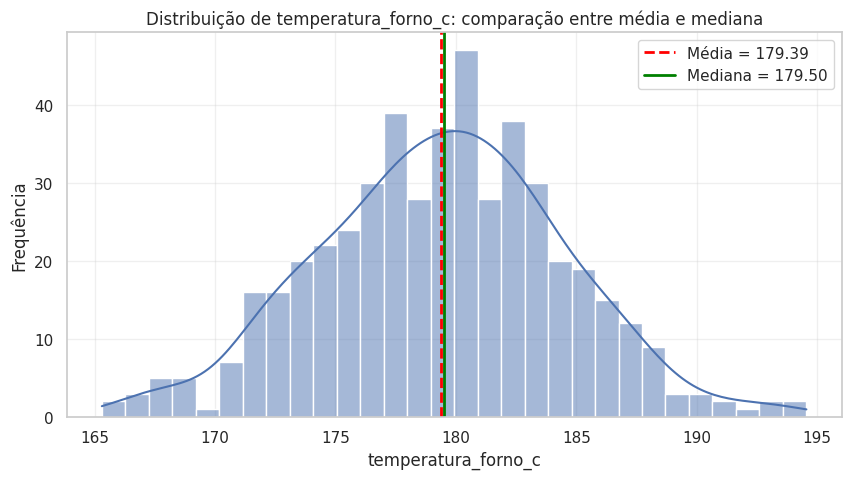

Moda de turno: Manhã


,temperatura_forno_c,temperatura_imputada_media,temperatura_imputada_mediana,turno,turno_imputado_moda
0,175.200,175.200,175.200,Noite,Noite
1,166.800,166.800,166.800,Manhã,Manhã
2,180.300,180.300,180.300,Manhã,Manhã
3,179.600,179.600,179.600,Tarde,Tarde
4,176.889,176.889,176.889,Manhã,Manhã
5,186.900,186.900,186.900,Manhã,Manhã
6,187.500,187.500,187.500,Noite,Noite
7,180.600,180.600,180.600,Noite,Noite
8,168.300,168.300,168.300,Noite,Noite
9,183.600,183.600,183.600,Manhã,Manhã


In [ ]:
# ------------------------------------------------------------
# 9) Exemplos de imputação com média, mediana e moda
# ------------------------------------------------------------

import matplotlib.pyplot as plt
import seaborn as sns

dados_imputacao_exemplo = dados_tratados.copy()

coluna_num = "temperatura_forno_c"

media_temp = dados_imputacao_exemplo[coluna_num].mean()
mediana_temp = dados_imputacao_exemplo[coluna_num].median()

print(f"Média de {coluna_num}: {media_temp:.2f}")
print(f"Mediana de {coluna_num}: {mediana_temp:.2f}")

# ------------------------------------------------------------
# Histograma para comparar visualmente média e mediana
# ------------------------------------------------------------

valores_observados = dados_imputacao_exemplo[coluna_num].dropna()

plt.figure(figsize=(10, 5))

sns.histplot(
    valores_observados,
    bins=30,
    kde=True
)

plt.axvline(
    media_temp,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Média = {media_temp:.2f}"
)

plt.axvline(
    mediana_temp,
    color="green",
    linestyle="-",
    linewidth=2,
    label=f"Mediana = {mediana_temp:.2f}"
)

plt.title(f"Distribuição de {coluna_num}: comparação entre média e mediana")
plt.xlabel(coluna_num)
plt.ylabel("Frequência")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Criamos duas colunas apenas para comparar as estratégias
dados_imputacao_exemplo["temperatura_imputada_media"] = (
    dados_imputacao_exemplo[coluna_num].fillna(media_temp)
)

dados_imputacao_exemplo["temperatura_imputada_mediana"] = (
    dados_imputacao_exemplo[coluna_num].fillna(mediana_temp)
)

# Exemplo com moda para uma variável categórica
moda_turno = dados_imputacao_exemplo["turno"].mode().iloc[0]
print(f"Moda de turno: {moda_turno}")

dados_imputacao_exemplo["turno_imputado_moda"] = (
    dados_imputacao_exemplo["turno"].fillna(moda_turno)
)

display(
    dados_imputacao_exemplo[
        [
            "temperatura_forno_c",
            "temperatura_imputada_media",
            "temperatura_imputada_mediana",
            "turno",
            "turno_imputado_moda"
        ]
    ].head(20)
)

### Interpretação das estratégias de imputação

A média e a mediana podem gerar valores parecidos quando a distribuição é aproximadamente simétrica.

Quando há outliers, a mediana costuma ser mais robusta. Por isso, em sensores industriais sujeitos a picos ou falhas, a mediana frequentemente é uma escolha inicial mais segura.

Para categorias, como `turno`, `maquina` e `produto`, a moda é uma estratégia simples: preencher com a categoria mais frequente.


## 11. Aplicando uma estratégia prática de imputação na base

Agora vamos aplicar uma estratégia simples:

- colunas numéricas: imputação pela mediana;
- colunas categóricas: imputação pela moda;
- datas ausentes: remoção das linhas sem data, pois o tempo da coleta é importante para rastreabilidade.

Principais recursos:

- `.select_dtypes(include="number")`: seleciona colunas numéricas.
- `.select_dtypes(include="object")`: seleciona colunas categóricas/textuais.
- `.dropna(subset=[...])`: remove linhas com ausência em colunas específicas.
- `.fillna(...)`: preenche valores ausentes.


In [ ]:
# ------------------------------------------------------------
# 10) Imputação prática na base tratada
# ------------------------------------------------------------

dados_imputados = dados_tratados.copy()

# Como a data é importante para rastreabilidade, vamos remover linhas sem data válida.
antes = len(dados_imputados)
dados_imputados = dados_imputados.dropna(subset=["data_coleta"])
depois = len(dados_imputados)

print(f"Linhas removidas por data inválida/ausente: {antes - depois}")

# Seleciona colunas numéricas e categóricas
colunas_numericas = list(dados_imputados.select_dtypes(include="number").columns)
colunas_categoricas = list(dados_imputados.select_dtypes(include="object").columns)

print("\nColunas numéricas:")
print(colunas_numericas)

print("\nColunas categóricas:")
print(colunas_categoricas)

# Imputação numérica pela mediana
for coluna in colunas_numericas:
    mediana = dados_imputados[coluna].median()
    dados_imputados[coluna] = dados_imputados[coluna].fillna(mediana)

# Imputação categórica pela moda
for coluna in colunas_categoricas:
    moda = dados_imputados[coluna].mode().iloc[0]
    dados_imputados[coluna] = dados_imputados[coluna].fillna(moda)

print("\nValores ausentes após imputação:")
display(dados_imputados.isna().sum().to_frame("ausentes"))

display(dados_imputados.head())


Linhas removidas por data inválida/ausente: 34

Colunas numéricas:
['id_registro', 'velocidade_esteira_m_min', 'vibracao_motor_mm_s', 'umidade_ambiente_pct', 'consumo_energia_kwh', 'consumo_energia_kwh_estimado', 'tempo_ciclo_s', 'taxa_defeitos_pct', 'temperatura_forno_c', 'pressao_linha_bar']

Colunas categóricas:
['maquina', 'turno', 'produto']

Valores ausentes após imputação:


,ausentes
id_registro,0
data_coleta,0
maquina,0
turno,0
produto,0
velocidade_esteira_m_min,0
vibracao_motor_mm_s,0
umidade_ambiente_pct,0
consumo_energia_kwh,0
consumo_energia_kwh_estimado,0


,id_registro,data_coleta,maquina,turno,produto,velocidade_esteira_m_min,vibracao_motor_mm_s,umidade_ambiente_pct,consumo_energia_kwh,consumo_energia_kwh_estimado,tempo_ciclo_s,taxa_defeitos_pct,temperatura_forno_c,pressao_linha_bar
0,1,2026-01-01 00:00:00,M3,Noite,Peça A,33.08,3.25,63.71,87.24,87.13,39.42,8.40,175.200,6.412
1,2,2026-01-01 01:00:00,M2,Manhã,Peça B,32.14,2.43,76.76,82.46,82.84,44.93,8.12,166.800,6.295
3,4,2026-01-01 03:00:00,M2,Tarde,Peça B,37.05,8.87,68.12,91.99,91.82,43.43,21.71,179.600,5.660
4,5,2026-01-01 04:00:00,M1,Manhã,Peça A,35.40,2.49,55.63,87.86,87.66,44.99,5.84,176.889,5.380
5,6,2026-01-01 05:00:00,M3,Manhã,Peça A,29.18,4.03,62.25,86.36,86.02,41.65,7.16,186.900,5.550


### Interpretação da imputação prática

Depois da imputação, a base fica sem valores ausentes nas colunas usadas.

Essa decisão não é universal. Em problemas reais, a escolha entre remover e imputar depende da quantidade de dados ausentes, da importância da variável e do mecanismo que gerou a ausência.

Para uma primeira análise didática, a imputação por mediana e moda é simples, interpretável e adequada.


## 12. Remoção de atributos quase redundantes por correlação alta

Além de colunas duplicadas exatamente, também podem existir colunas **quase redundantes**.

Por exemplo, uma coluna pode ser uma cópia aproximada de outra. Neste notebook, vamos detectar pares de variáveis numéricas com correlação muito alta.

Principais recursos:

- `.corr()`: calcula correlação entre variáveis numéricas.
- `.abs()`: usa valor absoluto da correlação.
- `np.triu(...)`: ajuda a olhar apenas metade superior da matriz, evitando repetir pares.
- `.drop(columns=...)`: remove atributos selecionados.

Atenção: remover variáveis por correlação deve ser feito com cuidado. Aqui o objetivo é didático.


#Uso de `np.triu()`:

```python
tri_superior = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
```

cria uma versão da matriz de correlação contendo **apenas a parte triangular superior**, ignorando a diagonal principal e a parte inferior da matriz.

Isso é útil porque a matriz de correlação é simétrica. Por exemplo, a correlação entre `temperatura` e `pressao` aparece duas vezes:

```text
corr(temperatura, pressao)
corr(pressao, temperatura)
```

Como os dois valores são iguais, basta analisar um deles.

---

Suponha uma matriz de correlação assim:

```text
              A      B      C
A           1.00   0.95   0.20
B           0.95   1.00   0.99
C           0.20   0.99   1.00
```

A parte triangular superior, sem a diagonal, seria:

```text
              A      B      C
A            NaN   0.95   0.20
B            NaN    NaN   0.99
C            NaN    NaN    NaN
```

Assim, cada par de colunas aparece apenas uma vez.

---

Agora, por partes:

```python
corr.shape
```

retorna o tamanho da matriz de correlação. Por exemplo, se houver 3 colunas numéricas:

```python
corr.shape
```

será:

```python
(3, 3)
```

---

```python
np.ones(corr.shape)
```

cria uma matriz do mesmo tamanho, preenchida com `1`.

Exemplo:

```text
[[1, 1, 1],
 [1, 1, 1],
 [1, 1, 1]]
```

---

```python
np.triu(np.ones(corr.shape), k=1)
```

pega apenas a parte triangular superior dessa matriz. O argumento `k=1` significa:

> comece uma diagonal acima da diagonal principal.

Portanto, a diagonal principal também será removida.

Resultado:

```text
[[0, 1, 1],
 [0, 0, 1],
 [0, 0, 0]]
```

Se fosse `k=0`, a diagonal principal seria mantida:

```text
[[1, 1, 1],
 [0, 1, 1],
 [0, 0, 1]]
```

Mas, no caso da correlação, não queremos a diagonal, porque ela representa a correlação da coluna com ela mesma, sempre igual a `1`.

---

```python
.astype(bool)
```

converte a matriz de `0` e `1` para valores booleanos:

```text
[[False, True, True],
 [False, False, True],
 [False, False, False]]
```

Essa matriz booleana será usada como máscara.

---

Por fim:

```python
corr.where(...)
```

mantém os valores de `corr` onde a máscara é `True` e substitui por `NaN` onde a máscara é `False`.

Ou seja:

```python
tri_superior = corr.where(mascara)
```

mantém apenas os valores da parte triangular superior.

---

Em resumo:

```python
tri_superior = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
```

> cria uma matriz de correlação sem repetir pares de colunas e sem considerar a correlação de uma coluna com ela mesma.

Ela é usada para evitar que o código detecte duas vezes o mesmo par altamente correlacionado.


In [ ]:
# ------------------------------------------------------------
# 11) Remoção de atributos quase redundantes por alta correlação
# ------------------------------------------------------------

dados_sem_atributos_redundantes = dados_imputados.copy()

colunas_numericas = list(dados_sem_atributos_redundantes.select_dtypes(include="number").columns)

corr = dados_sem_atributos_redundantes[colunas_numericas].corr().abs()

# Matriz triangular superior para não repetir pares
tri_superior = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

limite_correlacao = 0.98

colunas_corr_alta = [
    coluna for coluna in tri_superior.columns
    if any(tri_superior[coluna] > limite_correlacao)
]


for coluna in tri_superior.columns:
    correlacoes_altas = tri_superior[coluna][
        tri_superior[coluna] > limite_correlacao
    ]

    if not correlacoes_altas.empty:
        print(f"\nColuna analisada: {coluna}")

        for coluna_correlacionada, valor_corr in correlacoes_altas.items():
            print(
                f"  Correlacionada com: {coluna_correlacionada} "
                f"| correlação = {valor_corr:.4f}"
            )

print("Colunas candidatas à remoção por correlação muito alta:")
print(colunas_corr_alta)

dados_sem_atributos_redundantes = dados_sem_atributos_redundantes.drop(columns=colunas_corr_alta)

print("\nDimensões antes:", dados_imputados.shape)
print("Dimensões depois:", dados_sem_atributos_redundantes.shape)



Coluna analisada: consumo_energia_kwh_estimado
  Correlacionada com: consumo_energia_kwh | correlação = 0.9985
Colunas candidatas à remoção por correlação muito alta:
['consumo_energia_kwh_estimado']

Dimensões antes: (486, 14)
Dimensões depois: (486, 13)


### Interpretação da remoção por correlação

Correlação muito alta entre duas variáveis pode indicar que elas carregam praticamente a mesma informação.

Em modelos de aprendizado de máquina, atributos muito redundantes podem aumentar complexidade sem trazer muito ganho.

No entanto, a remoção não deve ser automática em todos os casos. É necessário considerar o significado físico de cada variável.


## 13. Visualização inicial dos outliers com boxplot

Antes de remover outliers, é importante visualizá-los.

O boxplot ajuda a identificar pontos muito distantes dos valores centrais.

Nesta célula, vamos observar algumas variáveis relevantes:

- vibração;
- pressão;
- temperatura;
- tempo de ciclo;
- taxa de defeitos.

Principais recursos:

- `sns.boxplot(...)`: cria boxplots.
- `plt.xticks(rotation=...)`: gira os nomes das variáveis para melhorar a leitura.


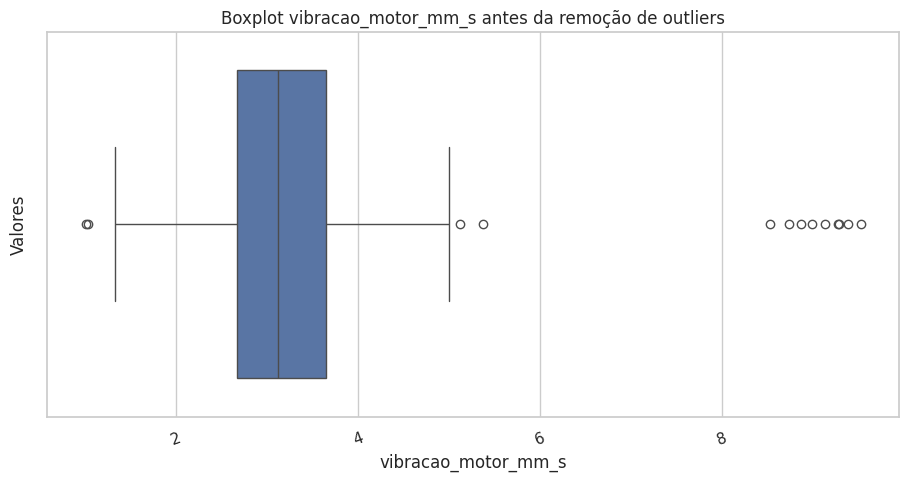

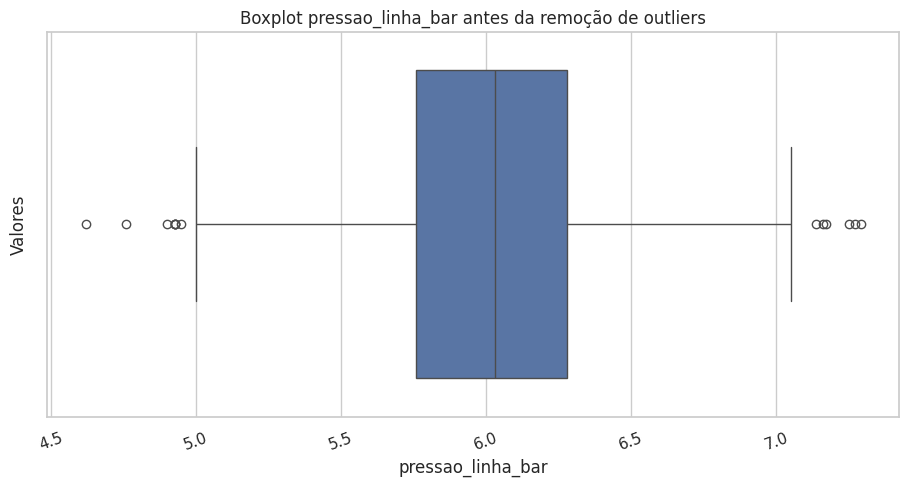

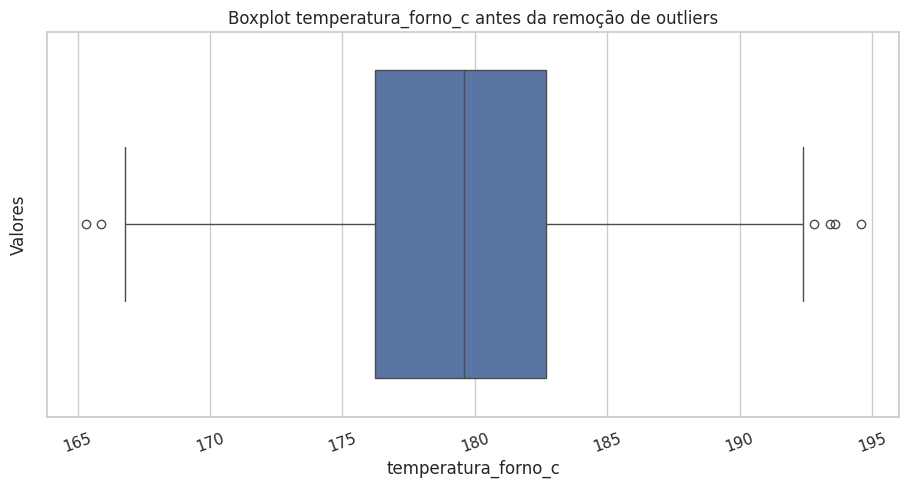

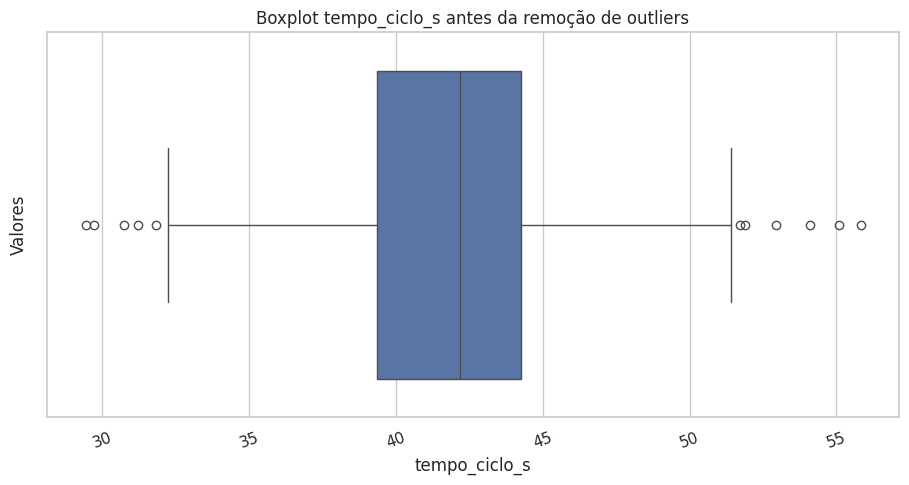

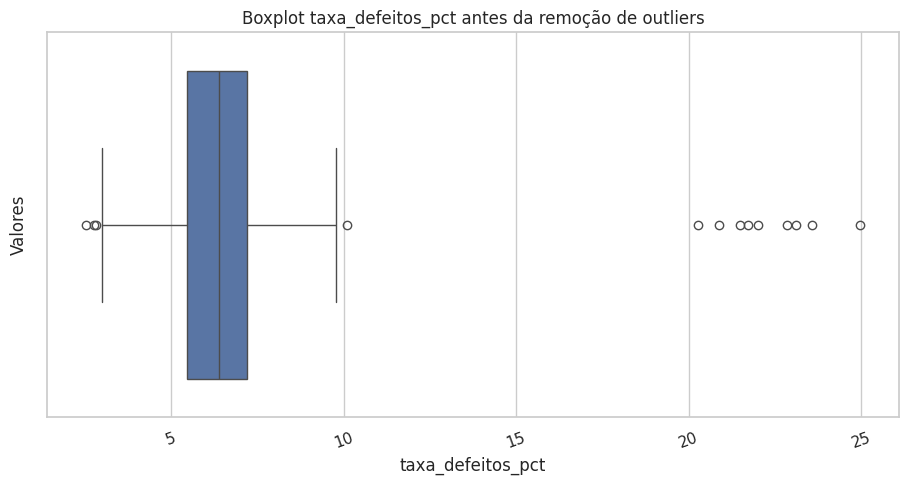

In [ ]:
# ------------------------------------------------------------
# 12) Boxplot antes da remoção de outliers
# ------------------------------------------------------------

dados_base_outliers = dados_sem_atributos_redundantes.copy()

variaveis_outliers = [
    "vibracao_motor_mm_s",
    "pressao_linha_bar",
    "temperatura_forno_c",
    "tempo_ciclo_s",
    "taxa_defeitos_pct"
]

for variavel in variaveis_outliers:
  plt.figure(figsize=(11, 5))
  sns.boxplot(x=dados_base_outliers[variavel])
  plt.title(f"Boxplot {variavel} antes da remoção de outliers")
  plt.xticks(rotation=20)
  plt.ylabel("Valores")
  plt.show()


### Interpretação do boxplot

Os boxplots indicam que a maior parte dos dados está concentrada em faixas relativamente estáveis, mas há vários valores extremos antes da remoção de outliers.

* **`vibracao_motor_mm_s`**: A maior parte dos valores está entre aproximadamente **2,7 e 3,7 mm/s**, com mediana perto de **3,1 mm/s**. Há poucos outliers baixos, próximos de **1**, e vários outliers altos, principalmente entre **8,5 e 9,5 mm/s**. Esses valores altos parecem bem distantes do padrão normal e merecem atenção.

* **`pressao_linha_bar`**: A pressão está concentrada em torno de **5,8 a 6,3 bar**, com mediana próxima de **6,0 bar**. Existem outliers tanto abaixo, perto de **4,6 a 4,9 bar**, quanto acima, perto de **7,1 a 7,3 bar**. A dispersão geral é moderada.

* **`temperatura_forno_c`**: A temperatura se concentra aproximadamente entre **176 e 183 ºC**, com mediana perto de **180 ºC**. Há alguns outliers baixos, próximos de **165–166 ºC**, e alguns altos, próximos de **193–195 ºC**. Apesar dos outliers, a distribuição central parece relativamente bem comportada.

* **`tempo_ciclo_s`**: O tempo de ciclo está concentrado entre aproximadamente **39 e 44,5 segundos**, com mediana perto de **42 segundos**. Há outliers baixos, próximos de **29–32 segundos**, e altos, próximos de **52–56 segundos**. Esses valores podem indicar ciclos anormalmente curtos ou longos.

* **`taxa_defeitos_pct`**: É a variável com os outliers mais evidentes. A maior parte dos valores está entre aproximadamente **5,5% e 7,2%**, com mediana perto de **6,3%**, mas há vários outliers altos entre **20% e 25%**. Isso indica forte assimetria à direita e sugere ocorrências anormais de defeitos.

###Conclusão:

De forma geral, os outliers mais críticos visualmente aparecem em **`taxa_defeitos_pct`** e **`vibracao_motor_mm_s`**, pois os valores extremos estão muito afastados da faixa central. Esses pontos podem ser erros, ruídos ou eventos industriais reais, como falhas, instabilidade operacional ou condições anormais de processo.


## 14. Remoção de outliers usando IQR

O IQR é o intervalo interquartil:

`IQR = Q3 - Q1`

O método define limites:

- limite inferior: `Q1 - fator * IQR`;
- limite superior: `Q3 + fator * IQR`.

O valor mais comum para `fator` é `1.5`.

Principais recursos:

- `.quantile(0.25)`: calcula Q1.
- `.quantile(0.75)`: calcula Q3.
- operadores lógicos: `>=`, `<=`, `&`.
- função Python para reaproveitar código.


Coluna: vibracao_motor_mm_s
Limite inferior: 1.20
Limite superior: 5.11
Linhas removidas: 13

Coluna: taxa_defeitos_pct
Limite inferior: 2.96
Limite superior: 9.63
Linhas removidas: 5

Dimensões antes: (486, 13)
Dimensões após IQR: (468, 13)


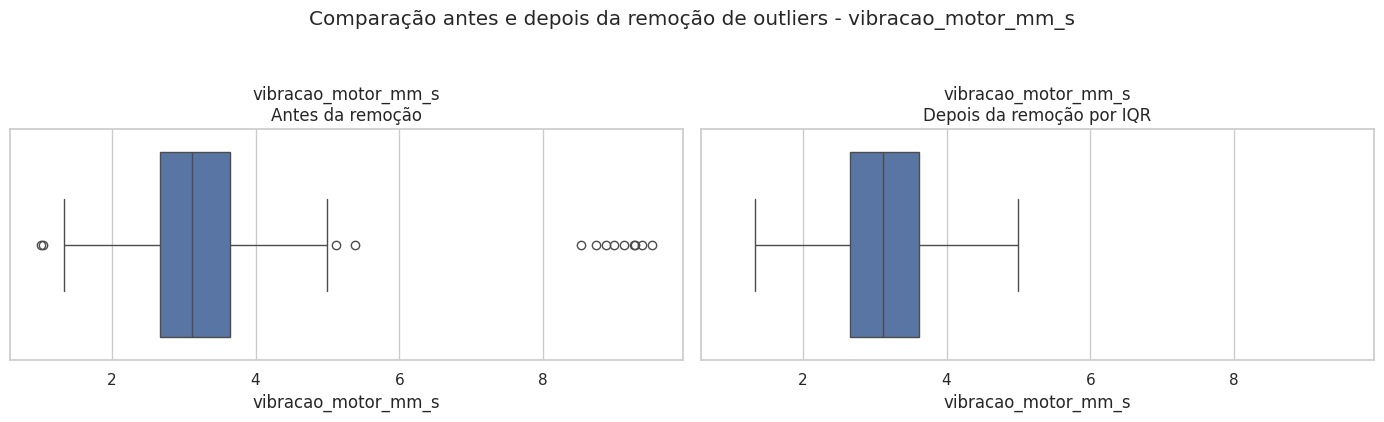

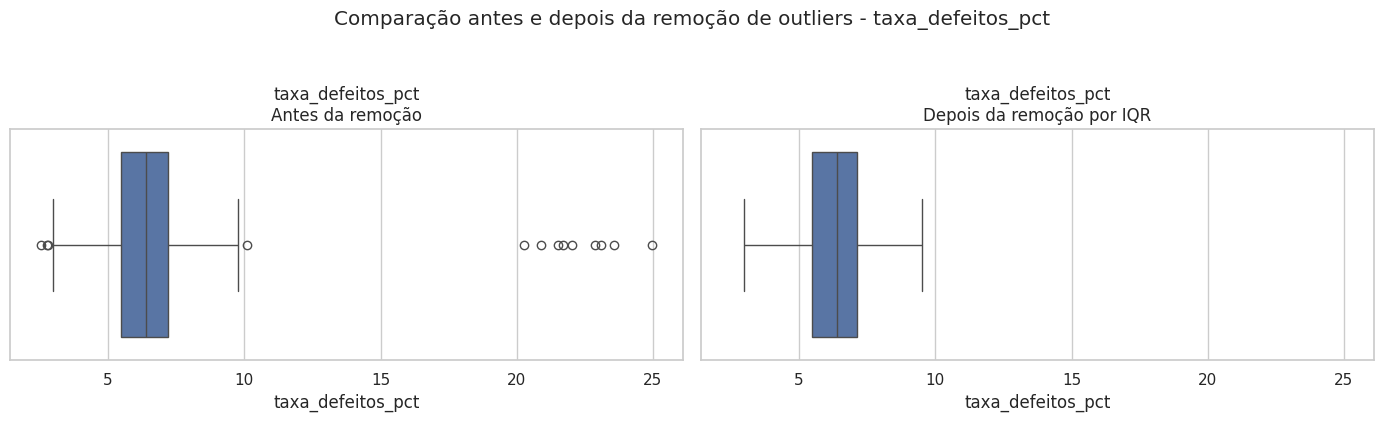

In [ ]:
# ------------------------------------------------------------
# 13) Remoção de outliers por IQR
# ------------------------------------------------------------

import matplotlib.pyplot as plt
import seaborn as sns

def remover_outliers_iqr(df, coluna, fator=1.5):
    """
    Remove linhas com valores fora dos limites definidos por IQR.

    Parâmetros:
    - df: DataFrame de entrada;
    - coluna: coluna analisada;
    - fator: multiplicador do IQR. O padrão 1.5 é bastante usado.
    """
    q1 = df[coluna].quantile(0.25)
    q3 = df[coluna].quantile(0.75)
    iqr = q3 - q1

    limite_inferior = q1 - fator * iqr
    limite_superior = q3 + fator * iqr

    mascara = (df[coluna] >= limite_inferior) & (df[coluna] <= limite_superior)

    return df[mascara].copy(), limite_inferior, limite_superior


dados_iqr = dados_base_outliers.copy()

colunas_outliers_iqr = [
    "vibracao_motor_mm_s",
    "taxa_defeitos_pct"
]

limites_iqr = {}

for coluna in colunas_outliers_iqr:
    antes = len(dados_iqr)

    dados_iqr, li, ls = remover_outliers_iqr(
        dados_iqr,
        coluna,
        fator=1.5
    )

    depois = len(dados_iqr)

    limites_iqr[coluna] = {
        "limite_inferior": li,
        "limite_superior": ls,
        "linhas_removidas": antes - depois
    }

    print(f"Coluna: {coluna}")
    print(f"Limite inferior: {li:.2f}")
    print(f"Limite superior: {ls:.2f}")
    print(f"Linhas removidas: {antes - depois}\n")

print("Dimensões antes:", dados_base_outliers.shape)
print("Dimensões após IQR:", dados_iqr.shape)


# ------------------------------------------------------------
# Boxplots antes e depois da remoção de outliers
# ------------------------------------------------------------

for coluna in colunas_outliers_iqr:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharex=True)

    sns.boxplot(
        x=dados_base_outliers[coluna],
        ax=axes[0]
    )

    axes[0].set_title(f"{coluna}\nAntes da remoção")
    axes[0].set_xlabel(coluna)

    sns.boxplot(
        x=dados_iqr[coluna],
        ax=axes[1]
    )

    axes[1].set_title(f"{coluna}\nDepois da remoção por IQR")
    axes[1].set_xlabel(coluna)

    plt.suptitle(
        f"Comparação antes e depois da remoção de outliers - {coluna}",
        y=1.05
    )

    plt.tight_layout()
    plt.show()

### Interpretação do IQR

O método IQR é simples e robusto, porque usa quartis em vez de média e desvio padrão.

Ele é útil quando queremos analisar outliers de uma variável específica, como vibração ou taxa de defeitos.

Limitação: o IQR é essencialmente univariado. Ele detecta valores extremos olhando uma variável por vez, mas pode não capturar combinações estranhas de variáveis.


## 15. Remoção de outliers usando z-score

O z-score mede quantos desvios padrão um valor está distante da média.

Um critério comum é considerar outlier quando:

`|z-score| > 3`

Principais recursos:

- `zscore(...)`: calcula z-score.
- `np.abs(...)`: calcula valor absoluto.
- `.all(axis=1)`: verifica se todas as variáveis de uma linha estão dentro do limite.
- `threshold`: parâmetro que controla o rigor do filtro.

Atenção: o z-score é mais adequado quando os dados são aproximadamente simétricos e sem caudas muito longas.


In [ ]:
# ------------------------------------------------------------
# 14) Remoção de outliers por z-score
# ------------------------------------------------------------

dados_zscore = dados_base_outliers.copy()

colunas_para_zscore = [
    "temperatura_forno_c",
    "pressao_linha_bar",
    "vibracao_motor_mm_s",
    "umidade_ambiente_pct",
    "tempo_ciclo_s",
    "taxa_defeitos_pct"
]

z = dados_zscore[colunas_para_zscore].apply(zscore)

limite_z = 3

# Mantém linhas em que todas as variáveis possuem |z| <= 3
mascara_sem_outlier = (np.abs(z) <= limite_z).all(axis=1)
#sso verifica, linha por linha, se todas as colunas daquela linha estão dentro do limite.
dados_zscore_filtrado = dados_zscore[mascara_sem_outlier].copy()

print("Dimensões antes:", dados_zscore.shape)
print("Dimensões após z-score:", dados_zscore_filtrado.shape)
print("Linhas removidas:", len(dados_zscore) - len(dados_zscore_filtrado))


Dimensões antes: (486, 13)
Dimensões após z-score: (470, 13)
Linhas removidas: 16


### Interpretação do z-score

O z-score compara cada valor com a média e o desvio padrão da variável.

Esse método é fácil de explicar, mas pode ser sensível a outliers, porque a média e o desvio padrão também são afetados por valores extremos.

Por isso, em dados industriais com picos, o IQR pode ser uma primeira alternativa mais robusta.


## 16. Remoção de outliers multivariados com DBSCAN

IQR e z-score analisam variáveis individualmente. O DBSCAN permite identificar pontos estranhos considerando várias variáveis ao mesmo tempo.

O DBSCAN agrupa pontos próximos. Pontos que não pertencem a nenhum grupo são marcados com rótulo `-1`, sendo candidatos a outliers.

Principais parâmetros:

- `eps`: distância máxima para considerar pontos como vizinhos. Valores menores tornam o método mais rigoroso.
- `min_samples`: número mínimo de pontos para formar uma região densa.
- `labels_`: rótulos atribuídos pelo algoritmo. O rótulo `-1` indica ruído/outlier.

Antes do DBSCAN, usamos `StandardScaler`, porque variáveis como temperatura, pressão e defeitos estão em escalas diferentes.


In [ ]:
# ------------------------------------------------------------
# 15) Remoção de outliers com DBSCAN
# ------------------------------------------------------------

dados_dbscan = dados_base_outliers.copy()

features_dbscan = [
    "temperatura_forno_c",
    "pressao_linha_bar",
    "vibracao_motor_mm_s",
    "umidade_ambiente_pct",
    "tempo_ciclo_s",
    "taxa_defeitos_pct"
]

# Padronização: cada variável passa a ter média 0 e desvio padrão 1
scaler = StandardScaler()
X_padronizado = scaler.fit_transform(dados_dbscan[features_dbscan])

# Ajuste do DBSCAN
# eps e min_samples devem ser ajustados conforme a base.
dbscan = DBSCAN(eps=1.8, min_samples=8)
rotulos = dbscan.fit_predict(X_padronizado)

dados_dbscan["rotulo_dbscan"] = rotulos
dados_dbscan["outlier_dbscan"] = dados_dbscan["rotulo_dbscan"] == -1

print("Contagem dos rótulos encontrados pelo DBSCAN:")
display(dados_dbscan["rotulo_dbscan"].value_counts().sort_index().to_frame("contagem"))

print("\nQuantidade de outliers DBSCAN:")
print(dados_dbscan["outlier_dbscan"].sum())

dados_dbscan_filtrado = dados_dbscan[dados_dbscan["outlier_dbscan"] == False].copy()
dados_dbscan_filtrado = dados_dbscan_filtrado.drop(columns=["rotulo_dbscan", "outlier_dbscan"])

print("\nDimensões antes:", dados_base_outliers.shape)
print("Dimensões após DBSCAN:", dados_dbscan_filtrado.shape)


Contagem dos rótulos encontrados pelo DBSCAN:


,contagem
rotulo_dbscan,
-1,14
0,472



Quantidade de outliers DBSCAN:
14

Dimensões antes: (486, 13)
Dimensões após DBSCAN: (472, 13)


### Interpretação do DBSCAN

O DBSCAN identifica pontos que não se encaixam bem em regiões densas dos dados.

Esse método é interessante quando um registro pode parecer normal em cada variável isoladamente, mas estranho na combinação das variáveis.

Por exemplo, uma temperatura aceitável combinada com pressão, vibração e defeitos em padrões incomuns pode ser marcada como ponto anômalo.

O ponto mais importante é que `eps` e `min_samples` precisam ser ajustados. Não existe um único valor ideal para todos os problemas.


## 17. Visualização dos outliers detectados pelo DBSCAN

Agora vamos visualizar os pontos marcados como outliers pelo DBSCAN em um scatter plot.

Usaremos:

- eixo X: `vibracao_motor_mm_s`;
- eixo Y: `taxa_defeitos_pct`;
- cor: se o ponto foi marcado como outlier ou não.

Principais recursos:

- `sns.scatterplot(...)`: gráfico de dispersão.
- `hue=...`: colore os pontos de acordo com uma variável.
- `alpha`: controla transparência.


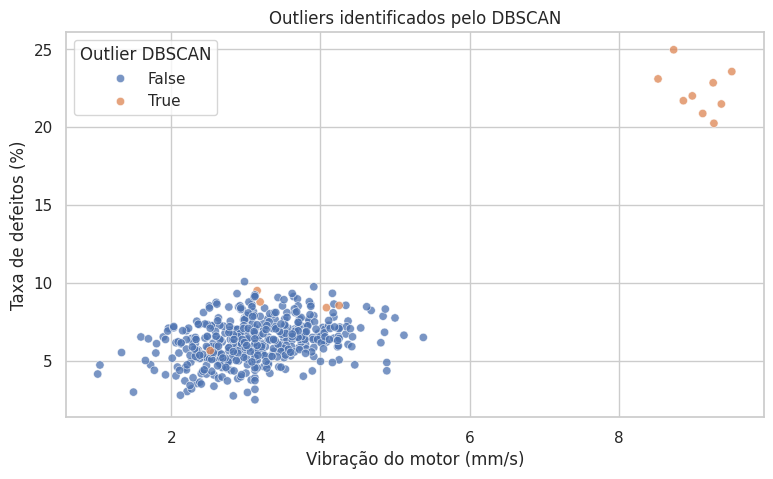

In [ ]:
# ------------------------------------------------------------
# 16) Visualização dos outliers DBSCAN
# ------------------------------------------------------------

plt.figure(figsize=(9, 5))

sns.scatterplot(
    data=dados_dbscan,
    x="vibracao_motor_mm_s",
    y="taxa_defeitos_pct",
    hue="outlier_dbscan",
    alpha=0.75
)

plt.title("Outliers identificados pelo DBSCAN")
plt.xlabel("Vibração do motor (mm/s)")
plt.ylabel("Taxa de defeitos (%)")
plt.legend(title="Outlier DBSCAN")
plt.show()


### Interpretação do gráfico DBSCAN

Os pontos marcados como `True` foram considerados ruído/outliers pelo DBSCAN.

Em um processo industrial, esses pontos devem ser analisados com cuidado. Eles podem indicar:

- falha real de operação;
- problema de sensor;
- erro de registro;
- condição rara, mas importante.

Em alguns casos, remover esses pontos é adequado. Em outros, eles são exatamente os casos mais importantes para investigar.


## 18. Comparação dos métodos de remoção de outliers

Agora vamos comparar quantas linhas foram mantidas por cada método.

Isso ajuda a entender que diferentes critérios podem remover quantidades diferentes de dados.

Importante:

- IQR é simples e robusto para análise univariada.
- z-score é simples, mas sensível a média e desvio padrão.
- DBSCAN é multivariado, mas depende de parâmetros como `eps` e `min_samples`.


,metodo,linhas_mantidas,linhas_removidas,percentual_removido
0,Base antes dos outliers,486,0,0.000
1,IQR,468,18,3.704
2,Z-score,470,16,3.292
3,DBSCAN,472,14,2.881


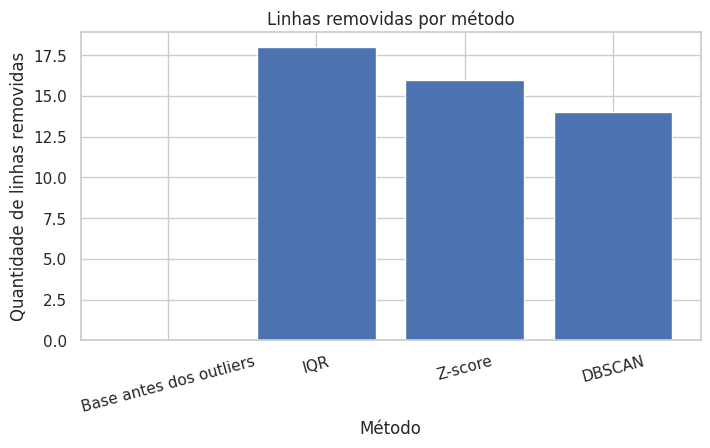

In [ ]:
# ------------------------------------------------------------
# 17) Comparação dos métodos
# ------------------------------------------------------------

comparacao = pd.DataFrame({
    "metodo": ["Base antes dos outliers", "IQR", "Z-score", "DBSCAN"],
    "linhas_mantidas": [
        len(dados_base_outliers),
        len(dados_iqr),
        len(dados_zscore_filtrado),
        len(dados_dbscan_filtrado)
    ]
})

comparacao["linhas_removidas"] = len(dados_base_outliers) - comparacao["linhas_mantidas"]
comparacao["percentual_removido"] = 100 * comparacao["linhas_removidas"] / len(dados_base_outliers)

display(comparacao)

plt.figure(figsize=(8, 4))
plt.bar(comparacao["metodo"], comparacao["linhas_removidas"])
plt.title("Linhas removidas por método")
plt.xlabel("Método")
plt.ylabel("Quantidade de linhas removidas")
plt.xticks(rotation=15)
plt.show()


### Interpretação da comparação

Não existe um método universalmente melhor para remoção de outliers.

A escolha depende do objetivo:

- para uma análise simples de uma variável, IQR pode ser suficiente;
- para dados aproximadamente normais, z-score pode ser útil;
- para detectar combinações estranhas de variáveis, DBSCAN pode ser mais adequado.

Em aplicações industriais, é recomendável validar os pontos removidos com especialistas do processo.


## 19. Salvando uma versão final da base tratada

Para finalizar, vamos escolher uma versão final da base tratada.

Neste exemplo, usaremos a base filtrada com DBSCAN apenas como demonstração. Em um projeto real, essa escolha deveria ser validada com o contexto do problema.

Principais recursos:

- `.to_csv("arquivo.csv", index=False)`: salva a base tratada em CSV.
- `index=False`: evita salvar o índice do Pandas como coluna.


In [ ]:
# ------------------------------------------------------------
# 18) Salvamento da base final tratada
# ------------------------------------------------------------

dados_final = dados_dbscan_filtrado.copy()

arquivo_final = "dados_linha_producao_limpos.csv"
dados_final.to_csv(arquivo_final, index=False)

print(f"Arquivo salvo: {arquivo_final}")
print("Dimensões finais:", dados_final.shape)

display(dados_final.head())


Arquivo salvo: dados_linha_producao_limpos.csv
Dimensões finais: (472, 13)


,id_registro,data_coleta,maquina,turno,produto,velocidade_esteira_m_min,vibracao_motor_mm_s,umidade_ambiente_pct,consumo_energia_kwh,tempo_ciclo_s,taxa_defeitos_pct,temperatura_forno_c,pressao_linha_bar
0,1,2026-01-01 00:00:00,M3,Noite,Peça A,33.08,3.25,63.71,87.24,39.42,8.40,175.200,6.412
1,2,2026-01-01 01:00:00,M2,Manhã,Peça B,32.14,2.43,76.76,82.46,44.93,8.12,166.800,6.295
4,5,2026-01-01 04:00:00,M1,Manhã,Peça A,35.40,2.49,55.63,87.86,44.99,5.84,176.889,5.380
5,6,2026-01-01 05:00:00,M3,Manhã,Peça A,29.18,4.03,62.25,86.36,41.65,7.16,186.900,5.550
6,7,2026-01-01 06:00:00,M1,Noite,Peça A,32.60,2.79,40.17,85.94,46.04,6.39,187.500,6.300


## 20. Conclusão

Neste notebook, percorremos um fluxo completo e didático de tratamento de dados:

1. Geração de uma base sintética com problemas.
2. Identificação de valores ausentes.
3. Remoção de linhas duplicadas.
4. Remoção de atributos redundantes.
5. Padronização de categorias.
6. Conversão de datas, temperaturas e pressões.
7. Tratamento de valores fisicamente inconsistentes.
8. Imputação com média, mediana e moda.
9. Remoção de outliers com IQR, z-score e DBSCAN.
10. Salvamento da base final limpa.

A principal mensagem é que tratamento de dados não é apenas uma etapa técnica. Ele exige interpretação do problema, conhecimento do domínio e cuidado para não remover informações importantes.

Em aprendizado de máquina, uma base bem tratada costuma ser tão importante quanto a escolha do modelo.


## 21. Atividade sugerida para os alunos

Use o notebook para responder:

1. Quais colunas tinham mais valores ausentes?
2. Quantas linhas duplicadas foram removidas?
3. Quais categorias estavam escritas de forma inconsistente?
4. Quantos registros foram removidos por IQR?
5. Quantos registros foram removidos por z-score?
6. Quantos registros foram marcados como outliers pelo DBSCAN?
7. O que acontece se você mudar `eps=1.8` para `eps=1.2` no DBSCAN?
8. O que acontece se você mudar o fator do IQR de `1.5` para `3.0`?

Essas perguntas ajudam a perceber que limpeza de dados envolve decisões e parâmetros ajustáveis.
